# TP vs. FP, by chromatin density and by raw `TM_CCOEFF` score

**Purpose.** `tp_fp_score_distribution.ipynb` plotted TP/FP separation in per-map robust `z`
units. This notebook adds two more views of the exact same candidate pool: **chromatin
density** (`chromatin.chromatin_density`, the `od` column `chromatin_od` ranks by), and
**raw `TM_CCOEFF` score** (the un-standardised value `z` is computed from). Same pool, same
bucket labels, same plot style -- different x-axis.

**A real bug this surfaced, fixed and verified below, not just assumed away.**
`chromatin_density` reads a 51x51 window around each candidate (`tm.read_padded_patch`) and
returns `NaN` when that window falls outside the image. Before `tm_threshold_axis_sweep_v2`'s
border-padding fix, no candidate could exist within ~25px of the ROI edge in the first place,
so this never came up. Now that padding makes the whole ROI reachable for matching, candidates
*do* land in that 25px margin -- and scoring their chromatin density against the **un-padded**
channel silently gives 669 of `301.tiff`'s 25,449 candidates a `NaN` `od` (measured below). The
fix is the same idea as the matching fix: score chromatin density against the **padded**
channel too, at shifted coordinates. Both the bug and the fix are shown with real counts, not
claimed.

**Why raw score gets its own panel instead of reusing the z-unit one.** `z` is a per-domain
linear rescaling of raw score (`z = (score - median) / mad`), so within one domain the two
panels are literally the same points in the same relative order -- only the x-axis numbers
change. The reason to look at raw score anyway is exactly to make that non-comparability
concrete: two domains at "the same" `z` can sit at very different raw `TM_CCOEFF` values,
which is the whole reason `z` was introduced as the threshold unit in the first place. Each
raw-score panel below marks where `z = 1.0` (the current floor) actually falls in that
domain's own raw units, so the two views can be read side by side.

In [1]:
import time
NB_T0 = time.time()

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from midog_utils import channels as ch
from midog_utils import chromatin as cm
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import experiment as ex
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
print('imports ok')

imports ok


## Configuration -- identical to `tp_fp_score_distribution.ipynb`

In [2]:
CHANNEL = 'hematoxylin_od'
METHOD = cv2.TM_CCOEFF
BASE_SIZE = tm.BASE_SIZE
PEAK_MIN_DISTANCE = 7
SEED_INDEX = 0
SELF_HIT_RADIUS = 5.0

DEEP_FLOOR_Z = -1.5
CURRENT_Z = 1.0
NMS_RADIUS_UM = 5.0
MATCH_RADIUS_UM = ev.MIDOG_RADIUS_UM
MAX_PEAKS = 2_000_000

FP_SUBSAMPLE_CAP = 8000
RNG_SEED = 0

CFG = fs.FSConfig(channel=CHANNEL, base_size=BASE_SIZE, scales=(1.0,),
                  n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE,
                  self_hit_radius=SELF_HIT_RADIUS)
BORDER = CFG.patch_size // 2

BUCKET_COLOR = {ev.HUMAN_CORRECT_LABEL: '#2ca02c',
               ev.HUMAN_REJECTED_LABEL: '#ff7f0e',
               ev.NON_HUMAN_FINDINGS: '#7f7f7f'}
BUCKET_LANE = {ev.HUMAN_CORRECT_LABEL: 2, ev.HUMAN_REJECTED_LABEL: 1, ev.NON_HUMAN_FINDINGS: 0}
STYLE = {
    ev.NON_HUMAN_FINDINGS: dict(s=5, alpha=0.10, zorder=1),
    ev.HUMAN_REJECTED_LABEL: dict(s=10, alpha=0.35, zorder=2),
    ev.HUMAN_CORRECT_LABEL: dict(s=22, alpha=0.9, zorder=3, edgecolors='#145214', linewidths=0.3),
}

## One ROI per domain

In [3]:
images, annotations = ds.load_annotations()
ds.check_invariants(annotations)
domain_images = ex.select_domain_images(images, annotations, images_dir='images')
domain_images = domain_images.sort_values('tumor_type').reset_index(drop=True)
domain_images[['tumor_type', 'file_name', 'image_id', 'n_mitotic']]

,tumor_type,file_name,image_id,n_mitotic
0,canine cutaneous mast cell tumor,301.tiff,301,218
1,canine lung cancer,201.tiff,201,18
2,canine lymphosarcoma,246.tiff,246,116
3,canine soft tissue sarcoma,459.tiff,459,131
4,human breast cancer,094.tiff,94,82
5,human melanoma,548.tiff,548,239
6,human neuroendocrine tumor,402.tiff,402,105


## Rebuild the deep pool, add chromatin density with the padding fix, bucket against GT

Same match -> pad -> crop -> extract -> NMS(decoupled radius) -> self-hit-drop as the last two
notebooks. Chromatin density is computed twice per domain: once "naively" against the
un-padded channel (to measure the `NaN` gap the border fix reopens for this second signal),
and once correctly against the padded channel at shifted coordinates (what's actually used).
`od_nan_fixed` must be `0` for every domain -- checked, not assumed -- since every candidate
now sits inside a `valid=True`, hence chromatin-scoreable, region by the same padding argument
`tm_threshold_axis_sweep_v2.ipynb` proved for matching.

In [4]:
pools = {}
nan_fix_rows = []

for _, row in domain_images.iterrows():
    fn, image_id, domain = row['file_name'], int(row['image_id']), row['tumor_type']
    t0 = time.time()

    rgb = ds.load_roi(f'images/{fn}')
    mpp = ds.roi_mpp(f'images/{fn}')
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)
    hem = ch.to_channel(rgb, CHANNEL)
    H, W = hem.shape[:2]
    gt = ds.image_annotations(annotations, fn)
    gt_mit = gt[gt['category_id'] == ds.MITOTIC]

    pool_seed, flagged = ss.agreement_pool(gt_mit)
    pool_seed = ss.border_filter(pool_seed, BORDER, rgb.shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])
    seed = pool_seed.iloc[int(rng.integers(len(pool_seed)))]
    seed_xy = (float(seed['cx']), float(seed['cy']))
    gt_eval = gt[gt['ann_id'] != int(seed['ann_id'])].reset_index(drop=True)

    patch = tm.read_padded_patch(hem, *seed_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch, CFG.base_size, CFG.scales,
                                          CFG.n_angles, CFG.flips)

    PAD = max((t.shape[0] - 1) // 2 for t in templates)
    hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
    fused_p, best_p, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize, method=METHOD)
    fused = fused_p[PAD:PAD + H, PAD:PAD + W]
    valid = valid_p[PAD:PAD + H, PAD:PAD + W]
    assert bool(valid.all()), f'{fn}: padding did not make the whole ROI valid'

    med, mad = tm.robust_stats(fused, valid)
    deep_floor = med + DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, deep_floor, MAX_PEAKS)

    keep = nms_by_distance(centers, scores, nms_radius)
    centers, scores = centers[keep], scores[keep]
    ok = np.hypot(centers[:, 0] - seed_xy[0], centers[:, 1] - seed_xy[1]) > CFG.self_hit_radius
    centers, scores = centers[ok], scores[ok]

    pool = pd.DataFrame({'cx': centers[:, 0], 'cy': centers[:, 1], 'score': scores})
    pool['z'] = (pool['score'] - med) / mad

    # --- chromatin density: naive (un-padded) vs. fixed (padded, shifted coords) ---
    od_naive = cm.score_detections(pool[['cx', 'cy']].copy(), hem)['od']
    shifted = pool[['cx', 'cy']].assign(cx=pool['cx'] + PAD, cy=pool['cy'] + PAD)
    od_fixed = cm.score_detections(shifted, hem_p)['od']
    pool['od'] = od_fixed.to_numpy()
    n_nan_naive = int(od_naive.isna().sum())
    n_nan_fixed = int(pool['od'].isna().sum())
    assert n_nan_fixed == 0, f'{fn}: {n_nan_fixed} candidates still NaN after the padding fix'
    nan_fix_rows.append({'file_name': fn, 'domain': domain, 'n_pool': len(pool),
                         'od_nan_naive': n_nan_naive, 'od_nan_fixed': n_nan_fixed})

    pool = pool.sort_values('score', ascending=False).reset_index(drop=True)
    det_out, gt_out = ev.bucket_detections(pool, gt_eval, match_radius)
    det_out['tumor_type'] = domain
    det_out['file_name'] = fn
    det_out['n_gt_mitotic'] = int((gt_eval['category_id'] == ds.MITOTIC).sum())
    det_out['map_median'] = med
    det_out['mad_scale'] = mad

    pools[fn] = det_out
    vc = det_out['bucket'].value_counts().to_dict()
    print(f"[{fn}] {domain:34s} n_pool={len(det_out):6d}  "
          f"TP={vc.get(ev.HUMAN_CORRECT_LABEL, 0):4d}  "
          f"FP_lookalike={vc.get(ev.HUMAN_REJECTED_LABEL, 0):4d}  "
          f"FP_unannotated={vc.get(ev.NON_HUMAN_FINDINGS, 0):6d}  "
          f"od_nan(naive->fixed)={n_nan_naive}->{n_nan_fixed}  [{time.time() - t0:.0f}s]",
          flush=True)

    del rgb, hem, hem_p, fused_p, valid_p, fused, valid
    import gc; gc.collect()

nan_fix_table = pd.DataFrame(nan_fix_rows)
print(f'\ntotal {time.time() - NB_T0:.0f}s')
nan_fix_table

[301.tiff] canine cutaneous mast cell tumor   n_pool= 25449  TP= 217  FP_lookalike= 109  FP_unannotated= 25123  od_nan(naive->fixed)=669->0  [14s]


[201.tiff] canine lung cancer                 n_pool= 22631  TP=  17  FP_lookalike=  49  FP_unannotated= 22565  od_nan(naive->fixed)=626->0  [14s]


[246.tiff] canine lymphosarcoma               n_pool= 29838  TP= 115  FP_lookalike= 123  FP_unannotated= 29600  od_nan(naive->fixed)=746->0  [13s]


[459.tiff] canine soft tissue sarcoma         n_pool= 18829  TP= 130  FP_lookalike=  89  FP_unannotated= 18610  od_nan(naive->fixed)=566->0  [10s]


[094.tiff] human breast cancer                n_pool= 28982  TP=  81  FP_lookalike= 102  FP_unannotated= 28799  od_nan(naive->fixed)=731->0  [20s]


[548.tiff] human melanoma                     n_pool= 20754  TP= 238  FP_lookalike= 118  FP_unannotated= 20398  od_nan(naive->fixed)=572->0  [22s]


[402.tiff] human neuroendocrine tumor         n_pool= 25759  TP= 104  FP_lookalike=  79  FP_unannotated= 25576  od_nan(naive->fixed)=645->0  [17s]



total 126s


,file_name,domain,n_pool,od_nan_naive,od_nan_fixed
0,301.tiff,canine cutaneous mast cell tumor,25449,669,0
1,201.tiff,canine lung cancer,22631,626,0
2,246.tiff,canine lymphosarcoma,29838,746,0
3,459.tiff,canine soft tissue sarcoma,18829,566,0
4,094.tiff,human breast cancer,28982,731,0
5,548.tiff,human melanoma,20754,572,0
6,402.tiff,human neuroendocrine tumor,25759,645,0


## Check the work: does this pool still match the sweep's saved numbers?

Same cross-check as `tp_fp_score_distribution.ipynb` -- filter this notebook's pool at every
swept `z` and compare `n_detections`/`full_list_recall` against
`results/tm_ccoeff_threshold_axis_sweep_v2.csv`. This doesn't depend on chromatin density at
all; it's here to confirm the underlying pool wasn't accidentally changed while adding the
`od` column.

In [5]:
v2 = pd.read_csv('results/tm_ccoeff_threshold_axis_sweep_v2.csv')
v2_ref = (v2[v2['arm'] == 'tm_score']
         .drop_duplicates(['file_name', 'z'])
         [['file_name', 'z', 'n_detections', 'full_list_recall', 'n_gt_mitotic']])

Z_CHECK = (-1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0)
mismatches = []
checked = 0
for fn, det_out in pools.items():
    for z in Z_CHECK:
        ref = v2_ref[(v2_ref['file_name'] == fn) & (np.isclose(v2_ref['z'], z))]
        if len(ref) == 0:
            continue
        ref = ref.iloc[0]
        cut = det_out['map_median'].iloc[0] + z * det_out['mad_scale'].iloc[0]
        sub = det_out[det_out['score'] >= cut]
        n_det = len(sub)
        tp = int((sub['bucket'] == ev.HUMAN_CORRECT_LABEL).sum())
        recall = tp / ref['n_gt_mitotic'] if ref['n_gt_mitotic'] else float('nan')
        checked += 1
        if n_det != int(ref['n_detections']) or not np.isclose(recall, ref['full_list_recall'], atol=1e-6):
            mismatches.append({'file_name': fn, 'z': z, 'n_detections_here': n_det,
                               'n_detections_v2': int(ref['n_detections'])})

print(f'{checked} (file, z) cells checked, {len(mismatches)} mismatches')
if mismatches:
    pd.DataFrame(mismatches)
else:
    print('exact match on n_detections and full_list_recall at every checked (file, z) cell -- '
         'the pool is unchanged; only the od column is new.')

63 (file, z) cells checked, 0 mismatches
exact match on n_detections and full_list_recall at every checked (file, z) cell -- the pool is unchanged; only the od column is new.


## Raw `TM_CCOEFF` score -- TP vs. FP, per domain

Same candidates, styling and subsampling rule as `tp_fp_score_distribution.ipynb`, plotted in
**raw score** instead of `z`. The dashed line marks `z = 1.0` translated into *this* domain's
own raw units (`map_median + 1.0 * mad_scale`, printed in the panel title) -- watch how much
that number itself moves between panels; that movement is the entire reason raw score cannot
be used as a shared threshold across domains.

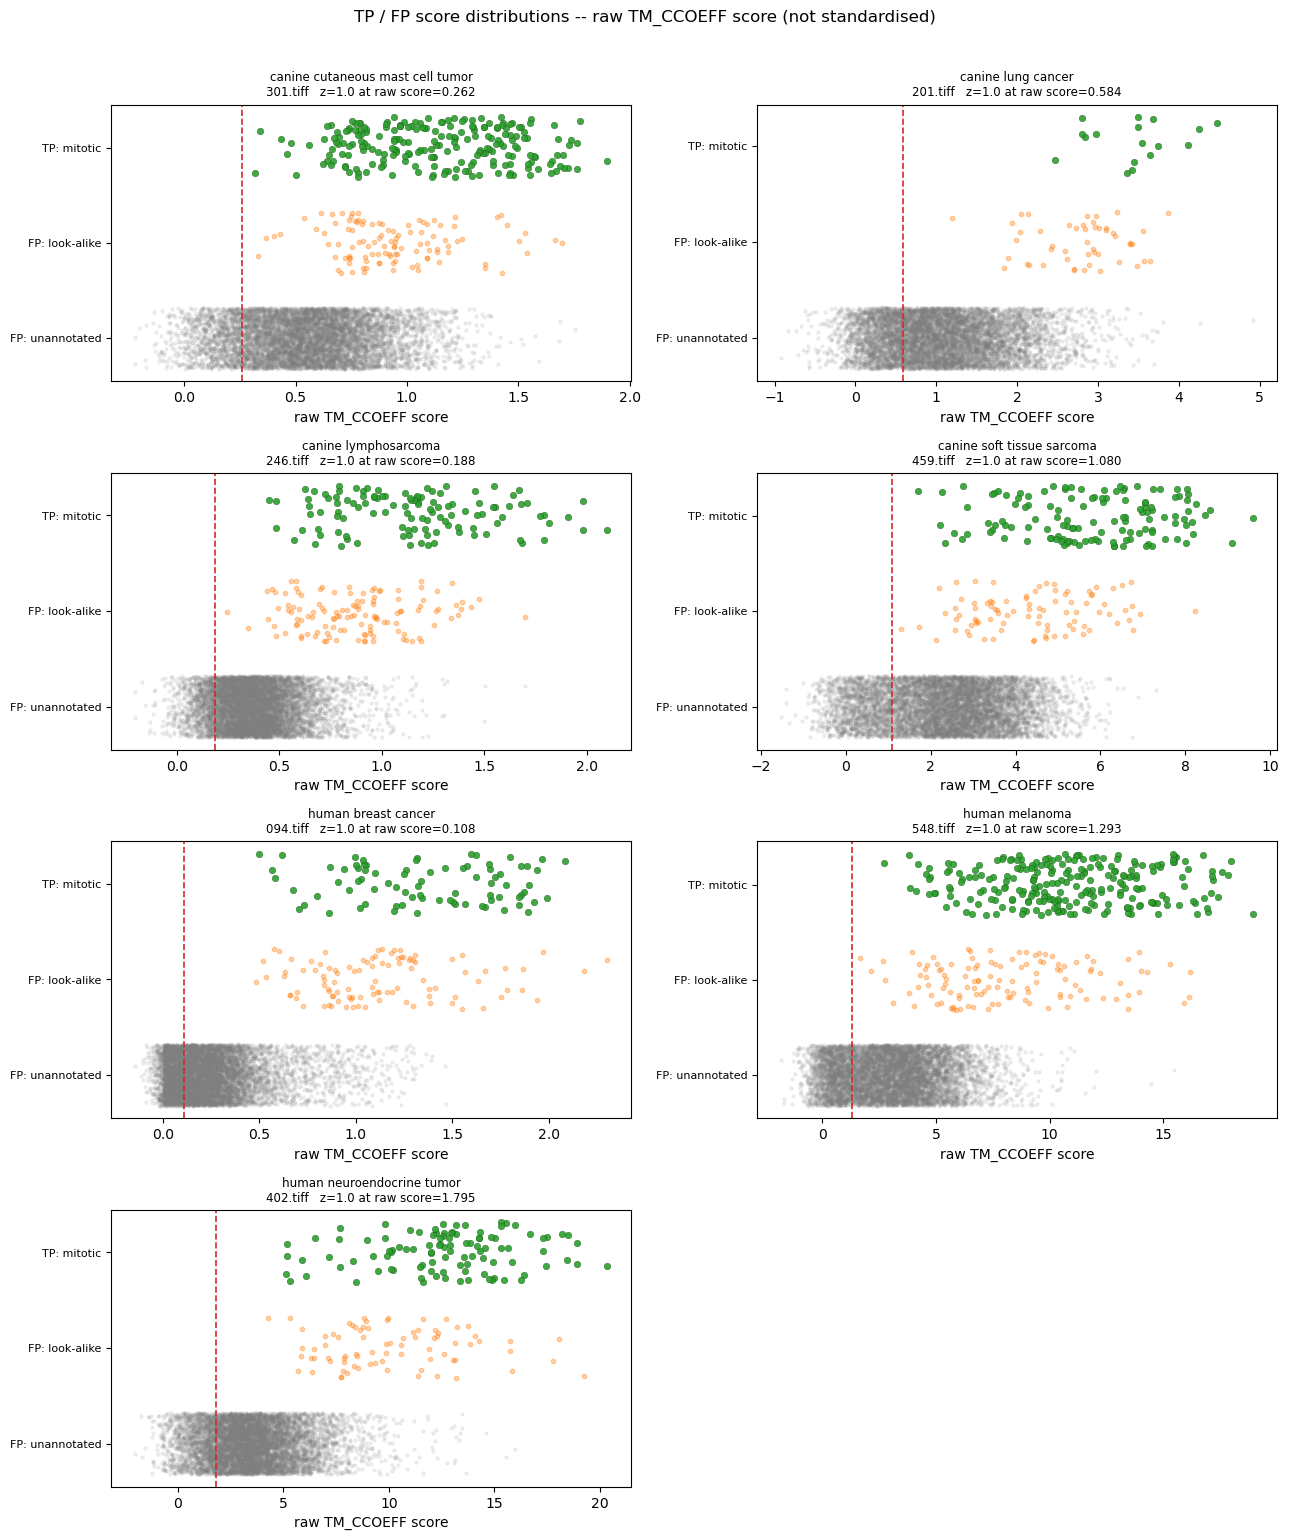

In [6]:
rng = np.random.default_rng(RNG_SEED)
domains_by_file = domain_images.set_index('file_name')['tumor_type'].to_dict()
files = list(domain_images.sort_values('tumor_type')['file_name'])
n = len(files)
ncols = 2
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows))
axes = np.atleast_1d(axes).ravel()
JITTER = 0.32

for ax, fn in zip(axes, files):
    domain = domains_by_file[fn]
    det_out = pools[fn]
    med = det_out['map_median'].iloc[0]
    mad = det_out['mad_scale'].iloc[0]
    cut_raw = med + CURRENT_Z * mad
    for bucket in (ev.NON_HUMAN_FINDINGS, ev.HUMAN_REJECTED_LABEL, ev.HUMAN_CORRECT_LABEL):
        sub = det_out[det_out['bucket'] == bucket]
        if bucket == ev.NON_HUMAN_FINDINGS and len(sub) > FP_SUBSAMPLE_CAP:
            idx = rng.choice(len(sub), size=FP_SUBSAMPLE_CAP, replace=False)
            sub = sub.iloc[idx]
        lane = BUCKET_LANE[bucket]
        y = lane + rng.uniform(-JITTER, JITTER, size=len(sub))
        ax.scatter(sub['score'], y, color=BUCKET_COLOR[bucket], **STYLE[bucket])

    ax.axvline(cut_raw, color='#d62728', linestyle='--', linewidth=1.2)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['FP: unannotated', 'FP: look-alike', 'TP: mitotic'], fontsize=8)
    ax.set_xlabel('raw TM_CCOEFF score')
    ax.set_title(f"{domain}\n{fn}   z=1.0 at raw score={cut_raw:.3f}", fontsize=8.5)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('TP / FP score distributions -- raw TM_CCOEFF score (not standardised)', y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

## Chromatin density -- TP vs. FP, per domain

`od` (`chromatin.chromatin_density`, the mean of the darkest 10% of a 51x51 window -- higher
means denser chromatin). No cutoff is drawn here: unlike `TM_CCOEFF`, chromatin density is not
currently used as a *filter* in this pipeline, only as the `chromatin_od` re-ranking key --
there is no `z=1.0`-equivalent decision on this axis yet to mark.

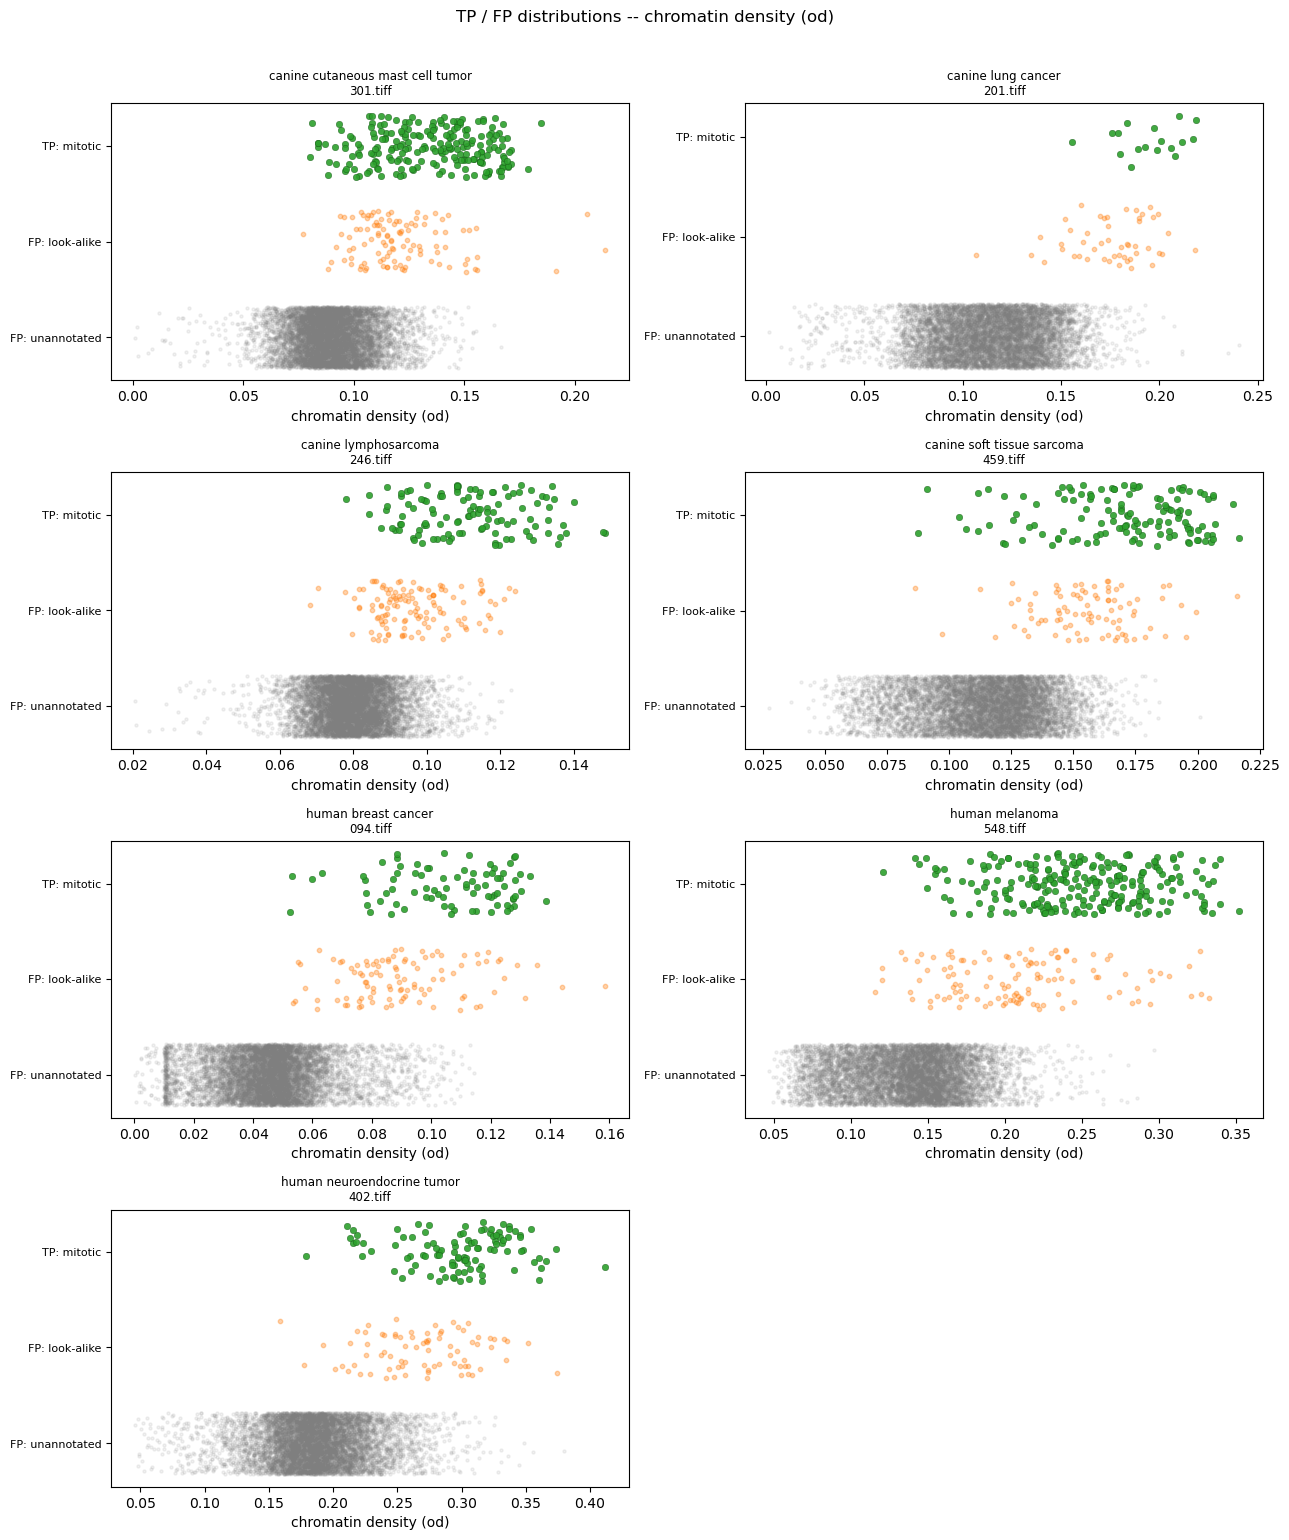

In [7]:
fig2, axes2 = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows))
axes2 = np.atleast_1d(axes2).ravel()

for ax, fn in zip(axes2, files):
    domain = domains_by_file[fn]
    det_out = pools[fn]
    for bucket in (ev.NON_HUMAN_FINDINGS, ev.HUMAN_REJECTED_LABEL, ev.HUMAN_CORRECT_LABEL):
        sub = det_out[det_out['bucket'] == bucket]
        if bucket == ev.NON_HUMAN_FINDINGS and len(sub) > FP_SUBSAMPLE_CAP:
            idx = rng.choice(len(sub), size=FP_SUBSAMPLE_CAP, replace=False)
            sub = sub.iloc[idx]
        lane = BUCKET_LANE[bucket]
        y = lane + rng.uniform(-JITTER, JITTER, size=len(sub))
        ax.scatter(sub['od'], y, color=BUCKET_COLOR[bucket], **STYLE[bucket])

    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['FP: unannotated', 'FP: look-alike', 'TP: mitotic'], fontsize=8)
    ax.set_xlabel('chromatin density (od)')
    ax.set_title(f"{domain}\n{fn}", fontsize=8.5)

for ax in axes2[n:]:
    ax.set_visible(False)

fig2.suptitle('TP / FP distributions -- chromatin density (od)', y=1.01, fontsize=12)
fig2.tight_layout()
plt.show()

## Which signal actually separates TP from FP better -- measured, not eyeballed

For each domain and each signal, the same statistic `tp_fp_score_distribution.ipynb` used for
`z`: the fraction of `non_human_findings` (the class driving candidate volume) whose value is
at or above the *lowest*-scoring TP on that signal. Lower means cleaner separation -- less of
the FP mass shares the TP's range, so a threshold on that signal removes more FP per TP lost.
`TM_CCOEFF` raw and `z` give the **identical** fraction on every domain -- `z` is a strictly
increasing per-domain transform of raw score, so it cannot change which points sort above or
below another point's value. That's asserted below, not just claimed.

In [8]:
sep_rows = []
for fn in files:
    det_out = pools[fn]
    tp = det_out[det_out['bucket'] == ev.HUMAN_CORRECT_LABEL]
    fpu = det_out[det_out['bucket'] == ev.NON_HUMAN_FINDINGS]
    if len(tp) == 0:
        continue
    tp_z_min = float(tp['z'].min())
    tp_score_min = float(tp['score'].min())
    tp_od_min = float(tp['od'].min())
    frac_z = float((fpu['z'] >= tp_z_min).mean())
    frac_score = float((fpu['score'] >= tp_score_min).mean())
    frac_od = float((fpu['od'] >= tp_od_min).mean())
    sep_rows.append({'tumor_type': domains_by_file[fn], 'file_name': fn, 'n_tp': len(tp),
                     'frac_fp_in_tp_range__tm_score': round(frac_score, 4),
                     'frac_fp_in_tp_range__tm_z': round(frac_z, 4),
                     'frac_fp_in_tp_range__chromatin_od': round(frac_od, 4),
                     'better_signal': 'chromatin_od' if frac_od < frac_score else 'tm_score'})

sep_table = pd.DataFrame(sep_rows).sort_values('tumor_type')
assert np.allclose(sep_table['frac_fp_in_tp_range__tm_score'],
                   sep_table['frac_fp_in_tp_range__tm_z']), \
    'raw score and z disagreed on separability -- the monotone-transform argument would be wrong'
print('raw-score and z separability match exactly on every domain (as they must): confirmed.')
sep_table

raw-score and z separability match exactly on every domain (as they must): confirmed.


,tumor_type,file_name,n_tp,frac_fp_in_tp_range__tm_score,frac_fp_in_tp_range__tm_z,frac_fp_in_tp_range__chromatin_od,better_signal
0,canine cutaneous mast cell tumor,301.tiff,217,0.8018,0.8018,0.7488,chromatin_od
1,canine lung cancer,201.tiff,17,0.0272,0.0272,0.0340,tm_score
2,canine lymphosarcoma,246.tiff,115,0.3000,0.3000,0.5642,tm_score
3,canine soft tissue sarcoma,459.tiff,130,0.6889,0.6889,0.8714,tm_score
4,human breast cancer,094.tiff,81,0.1042,0.1042,0.2925,tm_score
5,human melanoma,548.tiff,238,0.5282,0.5282,0.6929,tm_score
6,human neuroendocrine tumor,402.tiff,104,0.1813,0.1813,0.5923,tm_score


## Reading this

The `chromatin_od` fix mattered on its own terms -- without it, up to several hundred
candidates per domain (see the NaN table above) would have silently sorted to the bottom of
any `od`-ranked list regardless of how mitotic they actually looked, purely because of where
they happened to land relative to the crop edge, which is exactly the kind of border artefact
this whole line of work has been removing. With that fixed, the separability table gives a
direct, per-domain verdict on the open question from the last notebook: whether chromatin
density is actually a *cleaner* discriminator than `TM_CCOEFF` score, not just a differently
biased one. Where `better_signal == chromatin_od`, `chromatin_od` re-ranking is doing more than
moving good candidates up a tie-heavy list -- it is separating the classes better than the
search score can, on that domain's own numbers.